In [5]:
import os
import load_dotenv
from load_dotenv import load_dotenv

# This function will load all the variable from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv()

if os.environ.get("CLAUDE_API_KEY"):
    print("CLAUDE API KEY has been loaded")
else:
    raise ValueError("CLAUDE API KEY not found")

if os.environ.get("TAVILY_API_KEY"):
    print("TAVILY API KEY has been loaded")
else:
    raise ValueError("TAVILY API KEY not found")

CLAUDE API KEY has been loaded
TAVILY API KEY has been loaded


In [6]:
from langchain_anthropic import ChatAnthropic

llm_anthropic = ChatAnthropic(
    model = os.environ.get("CLAUDE_MODEL"),
    api_key = os.environ.get('CLAUDE_API_KEY'),
    temperature = 0,
    base_url = os.environ.get("CLAUDE_BASE_URL")
)
llm_anthropic

ChatAnthropic(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-anthropic': '1.5.5'}}, model='vertex_ai.anthropic.claude-opus-4-6', max_tokens=4096, temperature=0.0, anthropic_api_url='https://genai-sharedservice-americas.pwcinternal.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [ ]:
llm_anthropic.invoke("I want to know the meaning of water ").content

#### **First Graph**

#### Step-1: Define the Schema

In [8]:
from typing import TypedDict, List 

class graph_schema(TypedDict):
    name: str 
    message: str

#### Step-2: Create the Node Functions

In [9]:
# The state variable is defined of type graph_schema and this function welcome will return the variable of type graph_schema
def welcome(state: graph_schema) -> graph_schema:

    curr_name = state['name']
    curr_message = state['message']

    response = llm_anthropic.invoke(f"My name is {curr_name}. The message is {curr_message}").content

    state['message'] = f"Your message was {curr_message}. Here's my response - {response}"

    return state

#### Step-3: Create the State Graph

In [16]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome_bro", welcome)

# Adding Edges
# (Even for Single Node, the START and END Edge is to be created to inform Langchain about the START and END)
graph.add_edge(START, "welcome_bro")
graph.add_edge("welcome_bro", END)

#### Step-4: Compile the Graph

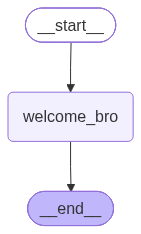

In [17]:
from IPython.display import Image, display

first_graph = graph.compile()

Image(first_graph.get_graph().draw_mermaid_png())
# print(first_graph.get_graph().draw_mermaid_png())

#### Step-5: Run the Graph

In [ ]:
first_graph.invoke({"name": "Sayani", "message": "How are you ?"})